In [ ]:
import os

def check_and_install(package_name):
    try:
        __import__(package_name)
    except ImportError:
        os.system(f'pip install {package_name}')

check_and_install('gdown')

import matplotlib.pyplot as plt
import pathlib
from glob import glob
from collections import defaultdict
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import math
import copy

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim.lr_scheduler import LambdaLR
from torchinfo import summary

# Dataset visualization

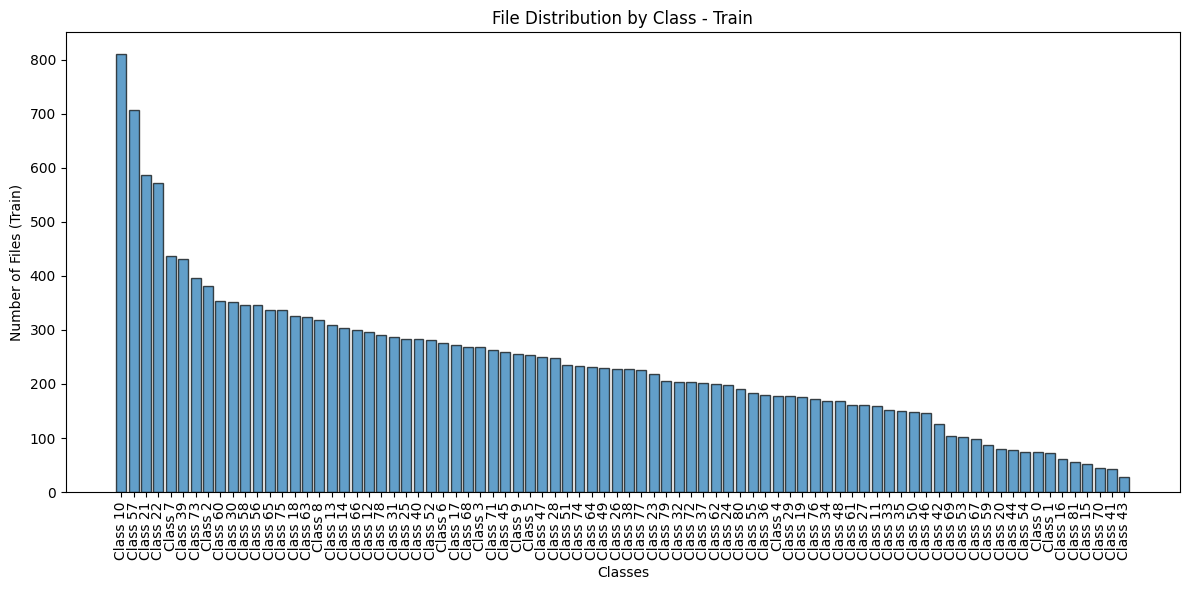

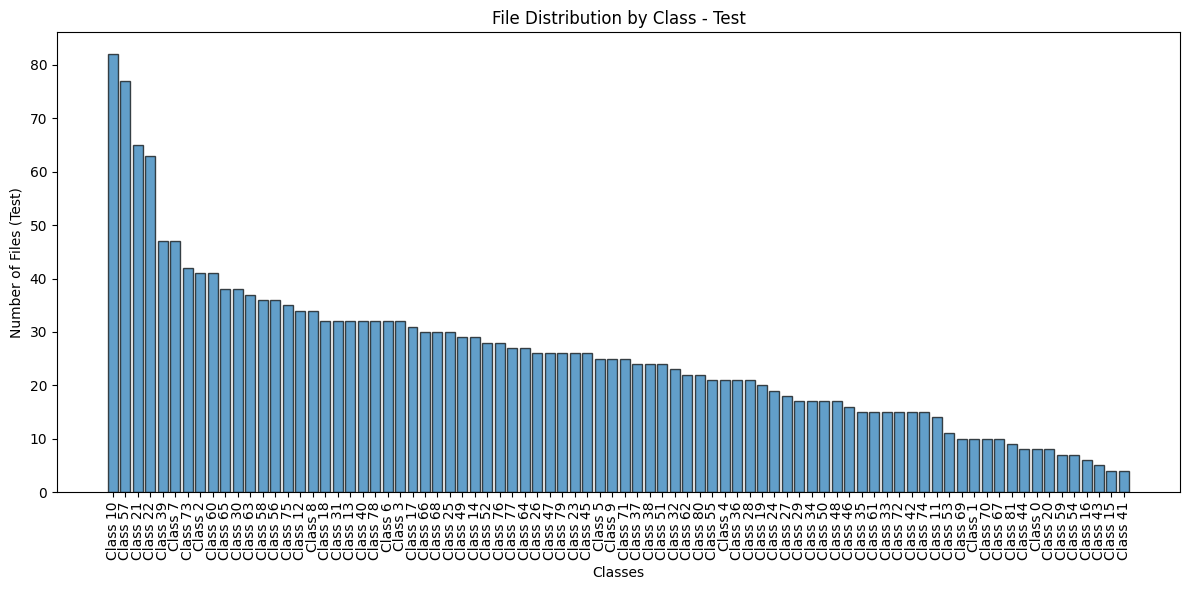

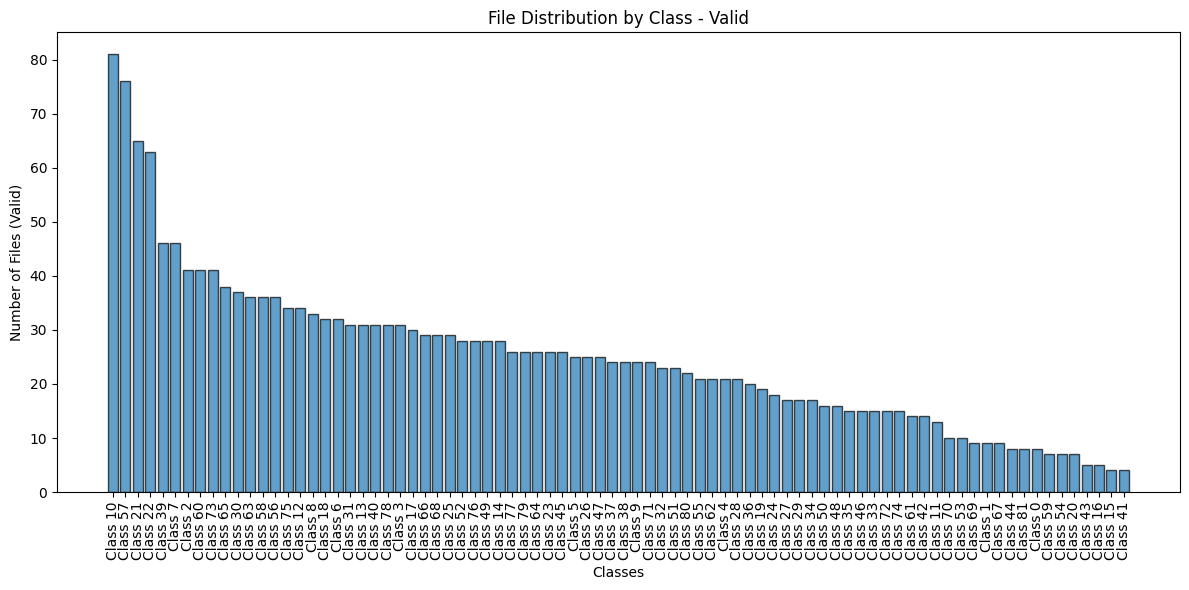


Contagem total por classe com nomes numerados e nomes reais (ordem alfabética):
Class 0 (Akarna_Dhanurasana): Train=74, Test=8, Valid=8, Total=90
Class 1 (Bharadvaja's_Twist_pose_or_Bharadvajasana_I_): Train=72, Test=10, Valid=9, Total=91
Class 2 (Boat_Pose_or_Paripurna_Navasana_): Train=382, Test=41, Valid=41, Total=464
Class 3 (Bound_Angle_Pose_or_Baddha_Konasana_): Train=268, Test=32, Valid=31, Total=331
Class 4 (Bow_Pose_or_Dhanurasana_): Train=178, Test=21, Valid=21, Total=220
Class 5 (Bridge_Pose_or_Setu_Bandha_Sarvangasana_): Train=254, Test=25, Valid=25, Total=304
Class 6 (Camel_Pose_or_Ustrasana_): Train=276, Test=32, Valid=32, Total=340
Class 7 (Cat_Cow_Pose_or_Marjaryasana_): Train=436, Test=47, Valid=46, Total=529
Class 8 (Chair_Pose_or_Utkatasana_): Train=318, Test=34, Valid=33, Total=385
Class 9 (Child_Pose_or_Balasana_): Train=256, Test=25, Valid=24, Total=305
Class 10 (Cobra_Pose_or_Bhujangasana_): Train=810, Test=82, Valid=81, Total=973
Class 11 (Cockerel_Pose): Train

In [ ]:
def count_files_in_all_splits(dataset_path):
    """
    Counts the number of files in each class for the train, test, and valid directories.

    :param dataset_path: Path to the dataset (main directory).
    :return: Dictionary with the class name as the key and the number of files per split as values.
    """
    splits = ['train', 'test', 'valid']  # Main subdirectories
    class_counts = defaultdict(lambda: {'train': 0, 'test': 0, 'valid': 0})

    for split in splits:
        split_path = dataset_path / split
        if not split_path.exists():
            print(f"Subdirectory {split} not found in {dataset_path}")
            continue

        for class_name in os.listdir(split_path):
            class_path = split_path / class_name
            if class_path.is_dir():
                # Count the files in the class folder
                file_count = len([f for f in class_path.iterdir() if f.is_file()])
                class_counts[class_name][split] = file_count

    return class_counts

# Path to the dataset
dataset_path = pathlib.Path('kp_ds_aug_2')  # Modify to the correct path

# Download and unzip the dataset, if necessary
if not dataset_path.exists():
    os.system('gdown 1Fjc-yTP9ovibz9QpECEY2uwonbroZQ1e -O dataset_keypoints_yoga.zip') # Drive ID
    os.system('unzip -q dataset_keypoints_yoga.zip')

# Count files in each class
class_file_counts = count_files_in_all_splits(dataset_path)

# Map classes to numbered names
class_name_map = {cls: f"Class {i}" for i, cls in enumerate(class_file_counts)}

# Generate histograms for each split with classes sorted in descending order by file count
for split in ['train', 'test', 'valid']:
    # Sort classes alphabetically to get the mapping
    sorted_class_names = sorted(class_file_counts.keys())  # Alphabetical order
    class_name_map = {cls: f"Class {i}" for i, cls in enumerate(sorted_class_names)}  # Numeric mapping

    # Sort classes by the number of files in the current subset
    sorted_classes_by_count = sorted(class_file_counts.items(), key=lambda x: x[1][split], reverse=True)

    # Map labels to the format "Class X (real_name)"
    classes = [class_name_map[cls] for cls, _ in sorted_classes_by_count]
    file_counts = [counts[split] for _, counts in sorted_classes_by_count]

    # Generate the histogram
    plt.figure(figsize=(12, 6))
    plt.bar(classes, file_counts, edgecolor='black', alpha=0.7)
    plt.xlabel("Classes")
    plt.ylabel(f"Number of Files ({split.capitalize()})")
    plt.title(f"File Distribution by Class - {split.capitalize()}")
    plt.xticks(rotation=90)  # Rotate class names for better readability
    plt.tight_layout()  # Adjust layout to avoid overlap
    plt.show()

sorted_class_names = sorted(class_file_counts.keys())  # Sort real class names alphabetically
class_name_map = {cls: f"Class {i}" for i, cls in enumerate(sorted_class_names)}

# Display total counts with numbered and real names in alphabetical order
print("\nTotal count per class with numbered and real names (alphabetical order):")
for class_name in sorted_class_names:
    mapped_name = class_name_map[class_name]
    counts = class_file_counts[class_name]
    total = sum(counts.values())
    print(f"{mapped_name} ({class_name}): Train={counts['train']}, Test={counts['test']}, Valid={counts['valid']}, Total={total}")

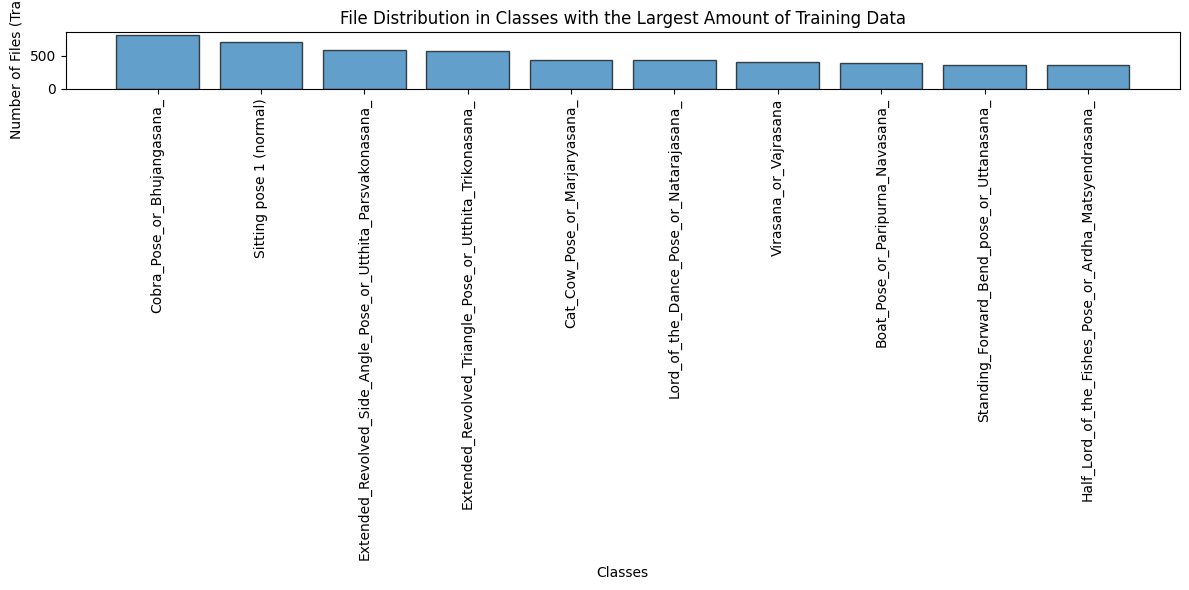


Number of training files in selected classes:
Cobra_Pose_or_Bhujangasana_: 810
Sitting pose 1 (normal): 706
Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_: 586
Extended_Revolved_Triangle_Pose_or_Utthita_Trikonasana_: 572
Cat_Cow_Pose_or_Marjaryasana_: 436
Lord_of_the_Dance_Pose_or_Natarajasana_: 432
Virasana_or_Vajrasana: 396
Boat_Pose_or_Paripurna_Navasana_: 382
Standing_Forward_Bend_pose_or_Uttanasana_: 354
Half_Lord_of_the_Fishes_Pose_or_Ardha_Matsyendrasana_: 352


In [ ]:
train_counts = {cls: counts['train'] for cls, counts in class_file_counts.items()}
sorted_train_classes = sorted(train_counts.items(), key=lambda x: x[1], reverse=True)

# Select the top 10 classes with the largest amount of training data
top_classes = sorted_train_classes[:10]

# Display histograms only for the top 10 classes with the most data in the "train" split
top_class_names = [cls for cls, _ in top_classes]
file_counts = [class_file_counts[cls]['train'] for cls in top_class_names]

plt.figure(figsize=(12, 6))
plt.bar(top_class_names, file_counts, edgecolor='black', alpha=0.7)
plt.xlabel("Classes")
plt.ylabel("Number of Files (Train)")
plt.title("File Distribution in Classes with the Largest Amount of Training Data")
plt.xticks(rotation=90)  # Rotate class names for better readability
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()

print("\nNumber of training files in selected classes:")
for cls, count in zip(top_class_names, file_counts):
    print(f"{cls}: {count}")

# Dataset preprocessing

In [ ]:
class NpyDataset(Dataset):
    def __init__(self, root_dir):
        files = glob(str(root_dir/'*/*.npy')) # local var, not Class property
        self.classes = np.array(sorted(i.name for i in pathlib.Path(root_dir).glob('*') if i.is_dir()))
        self.labels = np.array([
            np.searchsorted(self.classes, pathlib.Path(f).parent.name) for f in files
        ]) # maps every file to correspondent class using sorted self.classes as reference
        self.data = np.array([np.load(f) for f in files])
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.labels[idx])

In [ ]:
train_ds = NpyDataset(dataset_path/'train')
val_ds = NpyDataset(dataset_path/'valid')
test_ds = NpyDataset(dataset_path/'test')

In [ ]:
print(f"Tamanho do train_ds: {len(train_ds)}")
print(f"Tamanho do val_ds:   {len(val_ds)}")
print(f"Tamanho do test_ds:  {len(test_ds)}")

In [ ]:
for i in range(5):
    print(train_ds.data[i])

In [ ]:
class_names = train_ds.classes
num_classes = len(class_names)
print(class_names, num_classes)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=4, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True, prefetch_factor=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True, prefetch_factor=2)

In [ ]:
# Equivalente ao train_ds.take(1) para checar shapes
inputs, labels = next(iter(train_loader))
print(inputs.shape)   # torch.Size([32, 33, 4])
print(labels)

# Transformer with CNN extraction

## Initializer

In [ ]:
def he_uniform_(tensor):
    nn.init.kaiming_uniform_(tensor, nonlinearity='relu')

## Transformer Encoder

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, num_heads, dense_dim, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.layer_norm = nn.LayerNorm(dense_dim)

        self.mha = nn.MultiheadAttention(
            embed_dim=dense_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.dense_proj = nn.Sequential(
            nn.Linear(dense_dim, dense_dim),
            nn.ReLU(),
            nn.Linear(dense_dim, dense_dim),
            nn.ReLU(),
            nn.Linear(dense_dim, dense_dim)
        )

        for name, param in self.mha.named_parameters():
            if 'weight' in name:
                he_uniform_(param)

    def forward(self, x):

        att_out, _ = self.mha(x, x, x)
        proj_input = self.layer_norm(x + att_out)
        proj_output = self.dense_proj(proj_input)
        return self.layer_norm(proj_input + proj_output)

## Model architecture


In [ ]:
class YogaModel(nn.Module):
    def __init__(self, num_classes, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # MultiHeadAttention block
        self.input_proj = nn.Linear(4, 64)
        self.mha = nn.MultiheadAttention(embed_dim=4, num_heads=4, batch_first=True, )
        self.out_proj_mha = nn.Linear(64, 4)

        # Conv1 block
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=80, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(80)

        # Conv2 block
        self.conv2 = nn.Conv1d(in_channels=80, out_channels=48, kernel_size=5, padding='same')
        self.bn2   = nn.BatchNorm1d(48)
        self.drop1 = nn.Dropout(0.25)

        # Conv3 block
        self.conv3 = nn.Conv1d(in_channels=48, out_channels=16, kernel_size=5, padding='same')
        self.bn3   = nn.BatchNorm1d(16)

        # TransformerEncoder
        self.transformer = TransformerEncoder(num_heads=4, dense_dim=16)

        # MLP
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(33 * 16, 88)
        self.drop2 = nn.Dropout(0.5)
        self.fc_out = nn.Linear(88, num_classes)

    def forward(self, x):
        x_proj = self.input_proj(x) # (batch, 33, 4)  → (batch, 33, 64)
        attn_out, _ = self.mha(x_proj, x_proj, x_proj)
        x = x + self.out_proj_mha(attn_out)  # (batch, 33, 64) → (batch, 33, 4)

        # conv1d awaits inverse order (batch, channels, seq)
        x = x.permute(0, 2, 1)

        x = nn.functional.relu(self.bn1(self.conv1(x)))
        x = self.drop1(nn.functional.relu(self.bn2(self.conv2(x))))
        x = nn.functional.relu(self.bn3(self.conv3(x)))

        # transformer awaits reverse, wich means:
        x = x.permute(0, 2, 1)
        x = self.transformer(x)

        x = self.flatten(x)
        x = nn.functional.relu(self.fc1(x))
        x = self.drop2(x)
        return self.fc_out(x) # logits, without softmax
    
model = YogaModel(num_classes=num_classes)

In [ ]:
summary(model, input_size=(1, 33, 4))

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33            │ (None, 33, 4)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_33   │ (None, 33, 4)          │          1,220 │ input_layer_33[0][0],  │
│ (MultiHeadAttention)      │                        │                │ input_layer_33[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_12 (Add)              │ (None, 33, 4)          │              0 │ input_layer_33[0][0],  │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_36 (Conv1D)        │ (None, 33, 80)         │          1,680 │ add_12[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_35    │ (None, 33, 80)         │            320 │ conv1d_36[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_35             │ (None, 33, 80)         │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_37 (Conv1D)        │ (None, 33, 48)         │         19,248 │ activation_35[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_36    │ (None, 33, 48)         │            192 │ conv1d_37[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_36             │ (None, 33, 48)         │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_62 (Dropout)      │ (None, 33, 48)         │              0 │ activation_36[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_38 (Conv1D)        │ (None, 33, 16)         │          3,856 │ dropout_62[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_37    │ (None, 33, 16)         │             64 │ conv1d_38[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_37             │ (None, 33, 16)         │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ transformer_encoder       │ (None, 33, 16)         │          5,152 │ activation_37[0][0]    │
│ (TransformerEncoder)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_11 (Flatten) 

 Total params: 85,582 (334.30 KB)

 Trainable params: 85,294 (333.18 KB)

 Non-trainable params: 288 (1.12 KB)

## Model training

In [ ]:
# L2 Regularization (kernel regularizer)
optimizer = torch.optim.AdamW([
    {'params': model.conv1.parameters(),                          'weight_decay': 0},
    {'params': model.conv2.parameters(),                          'weight_decay': 1e-4},
    {'params': model.conv3.parameters(),                          'weight_decay': 1e-4},
    {'params': model.mha.parameters(),                            'weight_decay': 0},
    {'params': model.bn1.parameters(),                            'weight_decay': 0},
    {'params': model.bn2.parameters(),                            'weight_decay': 0},
    {'params': model.bn3.parameters(),                            'weight_decay': 0},
    {'params': model.transformer.parameters(),                    'weight_decay': 1e-4},
    {'params': model.fc1.parameters(),                            'weight_decay': 1e-4},
    {'params': model.fc_out.parameters(),                         'weight_decay': 0},
], lr=1e-3)

In [ ]:
# Scheduler
def scheduler(epoch):
    if epoch < 20:
        return 1.0
    else:
        return math.exp(-0.1 * (epoch - 19))

lr_scheduler = LambdaLR(optimizer, lr_lambda=scheduler)

In [ ]:
# Loss
criterion = nn.CrossEntropyLoss() # Sparse categorical crossentropy

In [ ]:
# Activity reg, Helpers for ModelCheckpoint + Early Stopping
activity_reg = 1e-5
best_val_acc = 0.0
best_weights = None
patience = 15
patience_count = 0

In [321]:
history = transformer.fit(
    train_ds,
    epochs=150,
    validation_data=val_ds,
    callbacks=callbacks)

Epoch 1/150
610/610 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2178 - loss: 3.5664
Epoch 1: val_accuracy improved from -inf to 0.71916, saving model to kp_ds_aug_2_model_1_tranformer_cnn.keras
610/610 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.2181 - loss: 3.5650 - val_accuracy: 0.7192 - val_loss: 1.1756 - learning_rate: 0.0010
Epoch 2/150
601/610 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6099 - loss: 1.5825
Epoch 2: val_accuracy improved from 0.71916 to 0.79132, saving model to kp_ds_aug_2_model_1_tranformer_cnn.keras
610/610 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6103 - loss: 1.5807 - val_accuracy: 0.7913 - val_loss: 0.8738 - learning_rate: 0.0010
Epoch 3/150
598/610 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7003 - loss: 1.2466
Epoch 3: val_accuracy improved from 0.79132 to 0.81570, saving model to kp_ds_aug_2_model_1_tranformer_cnn.keras
610/610 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7004 - loss: 1.2460 - val_accuracy: 0.8157 - val_loss: 0.8080 -

## Model metrics

Average loss and accuracy during training:
loss: 0.5929 - accuracy: 86.33%
Model validation:
loss: 0.5107 - accuracy: 90.20%


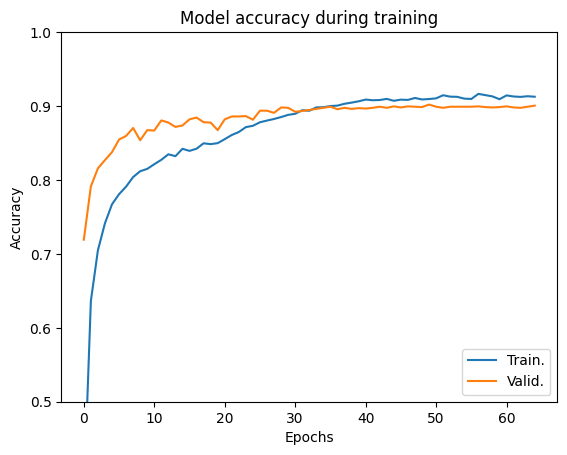

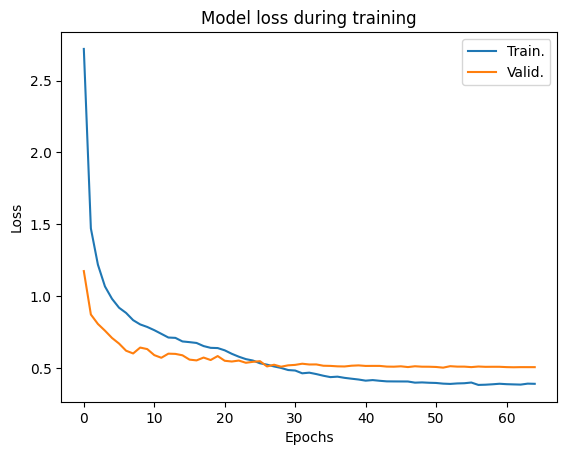

In [322]:
model = load_model("kp_ds_aug_2_model_1_tranformer_cnn.keras",
                   custom_objects={"TransformerEnconder": TransformerEncoder})

print("Average loss and accuracy during training:")
print(f"loss: {np.average(history.history['loss']):.4f} - accuracy: {np.average(history.history['accuracy']) * 100:.2f}%")

print("Model validation:")
scores = model.evaluate(val_ds, verbose=0)
print(f'loss: {scores[0]:.4f} - accuracy: {scores[1]* 100:.2f}%')

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy during training')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train.', 'Valid.'], loc='lower right')
plt.ylim(0.5, 1.0)
plt.show()

print("\n")

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss during training')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train.', 'Valid.'], loc='upper right')
plt.show()

In [323]:
scores = model.evaluate(test_ds, verbose=0)
print("Model testing:")
print(f'loss: {scores[0]:.4f} - accuracy: {scores[1]* 100:.2f}%')

Model testing:
loss: 0.5364 - accuracy: 90.31%


In [ ]:
mapped_class_names = [class_name_map[cls] for cls in sorted_class_names]  # List of mapped class names

y_pred = np.argmax(model.predict(test_ds), axis=1)  # Get predictions based on probabilities
y_true = np.concatenate([label.numpy() for kp, label in test_ds], axis=0)  # Get true labels

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


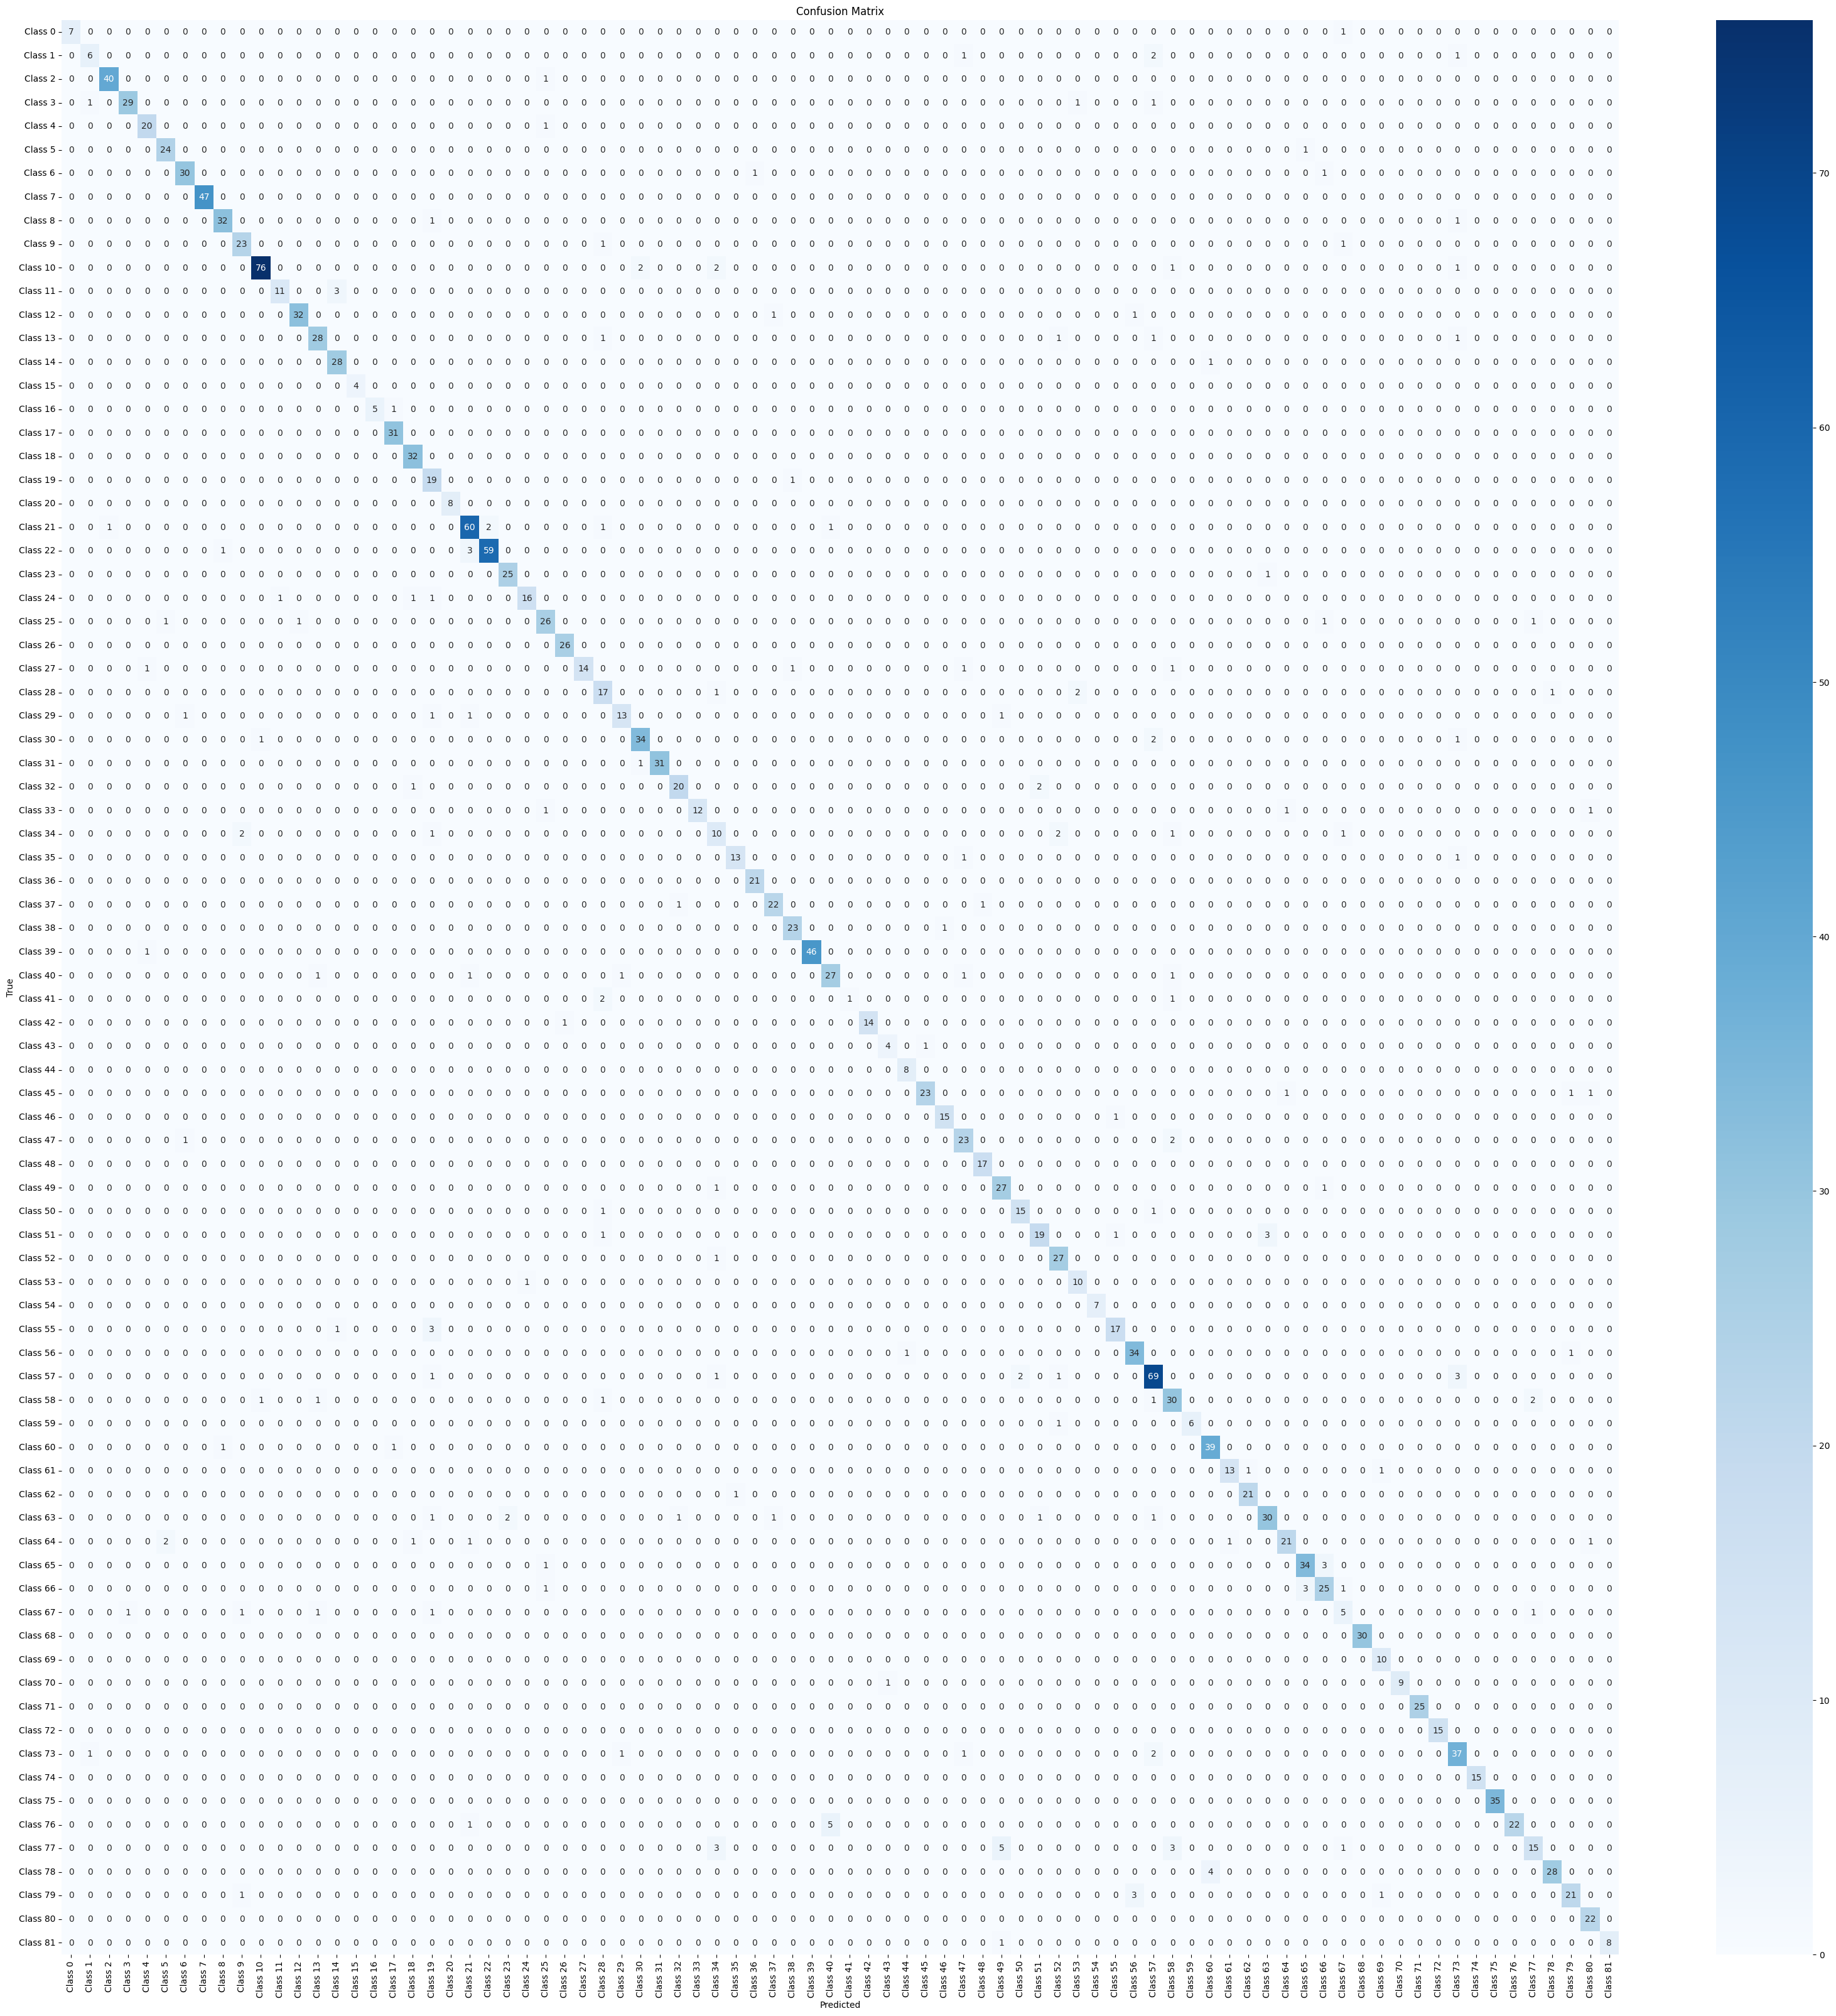

In [ ]:
# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(40, 40))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapped_class_names,
            yticklabels=mapped_class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification report
report = classification_report(y_true, y_pred, target_names=mapped_class_names, output_dict=True)
report_df = pd.DataFrame(report)
report_df.to_csv("kp_ds_aug_2_report_transformer.csv", index=True)
report_df

,Class 0,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7,Class 8,Class 9,...,Class 75,Class 76,Class 77,Class 78,Class 79,Class 80,Class 81,accuracy,macro avg,weighted avg
precision,1.000000,0.750000,0.97561,0.966667,0.909091,0.888889,0.9375,1.0,0.941176,0.851852,...,1.0,1.000000,0.789474,0.965517,0.913043,0.88000,1.000000,0.903149,0.904835,0.907305
recall,0.875000,0.600000,0.97561,0.906250,0.952381,0.960000,0.9375,1.0,0.941176,0.920000,...,1.0,0.785714,0.555556,0.875000,0.807692,1.00000,0.888889,0.903149,0.886643,0.903149
f1-score,0.933333,0.666667,0.97561,0.935484,0.930233,0.923077,0.9375,1.0,0.941176,0.884615,...,1.0,0.880000,0.652174,0.918033,0.857143,0.93617,0.941176,0.903149,0.890461,0.902779
support,8.000000,10.000000,41.00000,32.000000,21.000000,25.000000,32.0000,47.0,34.000000,25.000000,...,35.0,28.000000,27.000000,32.000000,26.000000,22.00000,9.000000,0.903149,2096.000000,2096.000000
